### Student Performance Analysis 

### Problem Statement
This project aims to understand and predict students' academic performance (math, reading, and writing scores) based on demographic and socio-economic factors gender, ethnicity, parental level of education, lunch type, and completion of the test preparation course. The goal is to identify which of these factors most strongly influence exam performance, and to build a model that can predict a student's score from these inputs.

### Importing necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import the Student CSV Data as Pandas Dataframe

In [4]:
data=df = pd.read_csv('data/student.csv')

In [5]:
data.head( )

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Data Manipulation

In [6]:
# Checking duplicates
data.duplicated().sum()

np.int64(0)

In [7]:
# Missing value
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
# Check Null and DataTypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Exploratory Data Analysis

In [11]:
print("Categories in 'gender' variable:                  ", end=" ")
print(data['gender'].unique())

print("Categories in 'race/ethnicity' variable:           ", end=" ")
print(data['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:", end=" ")
print(data['parental level of education'].unique())

print("Categories in 'lunch' variable:                    ", end=" ")
print(data['lunch'].unique())

print("Categories in 'test preparation course' variable:  ", end=" ")
print(data['test preparation course'].unique())

Categories in 'gender' variable:                   ['female' 'male']
Categories in 'race/ethnicity' variable:            ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:                     ['standard' 'free/reduced']
Categories in 'test preparation course' variable:   ['none' 'completed']


In [12]:
# define numerical and categorical columns
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### Add columns for "Total Score and Average"


In [18]:
data['total score'] = data['math score'] + data['reading score'] + data['writing score']
data['average'] = data['total score'] /3
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
reading_full = data[data['reading score'] == 100]['average'].count()
writing_full = data[data['writing score'] == 100]['average'].count()
math_full = data[data['math score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with marks in Writing:  {writing_full}')
print(f'Number of Students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with marks in Writing:  14
Number of Students with full marks in Reading: 17


In [24]:
# checking students below average 

reading_below_20 = data[data['reading score'] <= 20]['average'].count()
writing_below_20 = data[data['writing score'] <= 20]['average'].count()
math_below_20 = data[data['math score'] <= 20]['average'].count()

print(f'Number of students below 20 marks in Maths: {math_below_20}')
print(f'Number of students below 20 marks in Writing {writing_below_20}')
print(f'Number of students below 20 marks in Reading: {reading_below_20}')

Number of students below 20 marks in Maths: 4
Number of students below 20 marks in Writing 3
Number of students below 20 marks in Reading: 1


### From my analysis, I found that students performed better in reading than in mathematics — four students scored below 20 marks in maths.

### Visualisation 
- Using Histogram and KDE

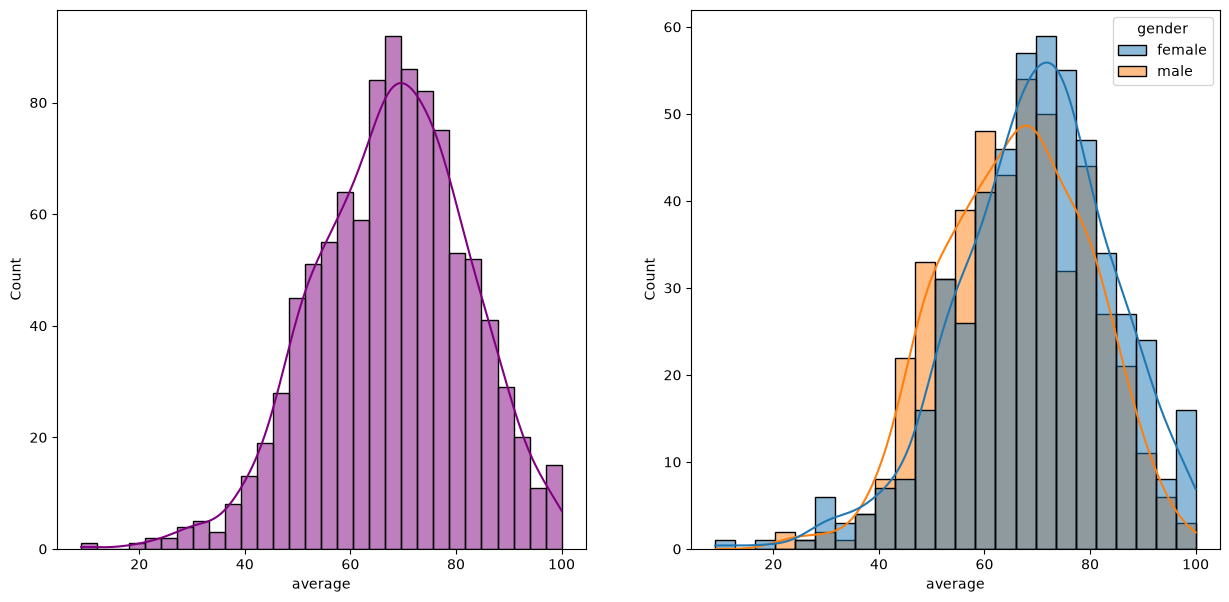

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=data, x='average', bins=30, kde=True, color='purple')

plt.subplot(122)
sns.histplot(data=data, x='average', kde=True, hue='gender')

plt.savefig('images/average_score_distribution.png')
plt.show()

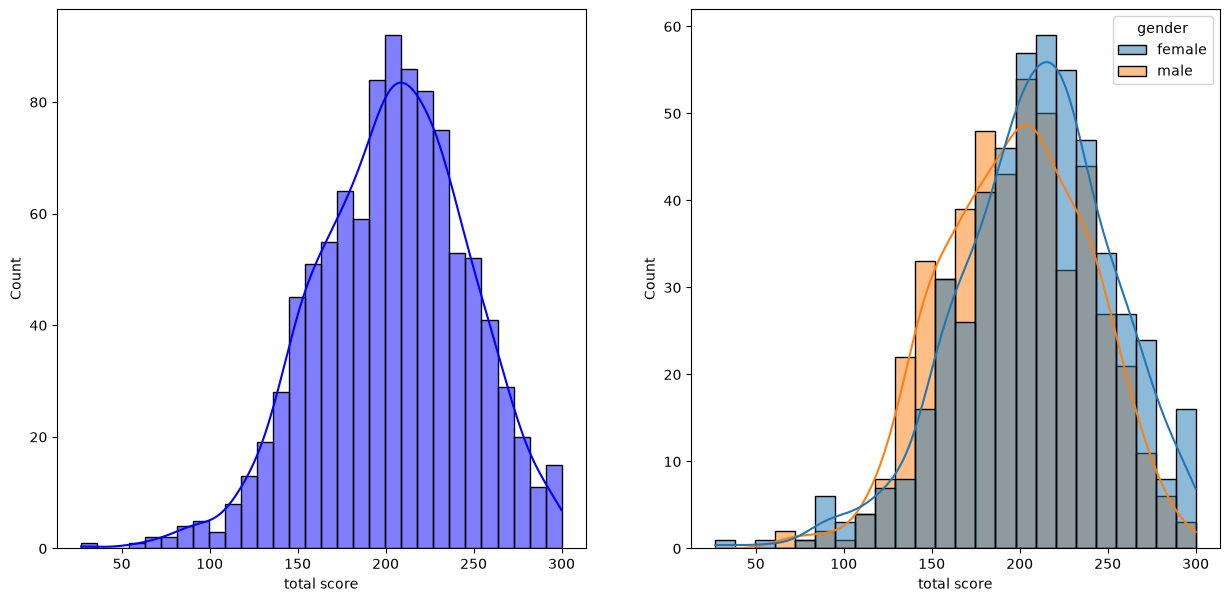

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=data, x='total score', bins=30, kde=True, color='blue')

plt.subplot(122)
sns.histplot(data=data, x='total score', kde=True, hue='gender')

plt.savefig('images/total_score_distribution.png')
plt.show()

### Looking at the visuals above, I can see that female students tend to perform better than male students.

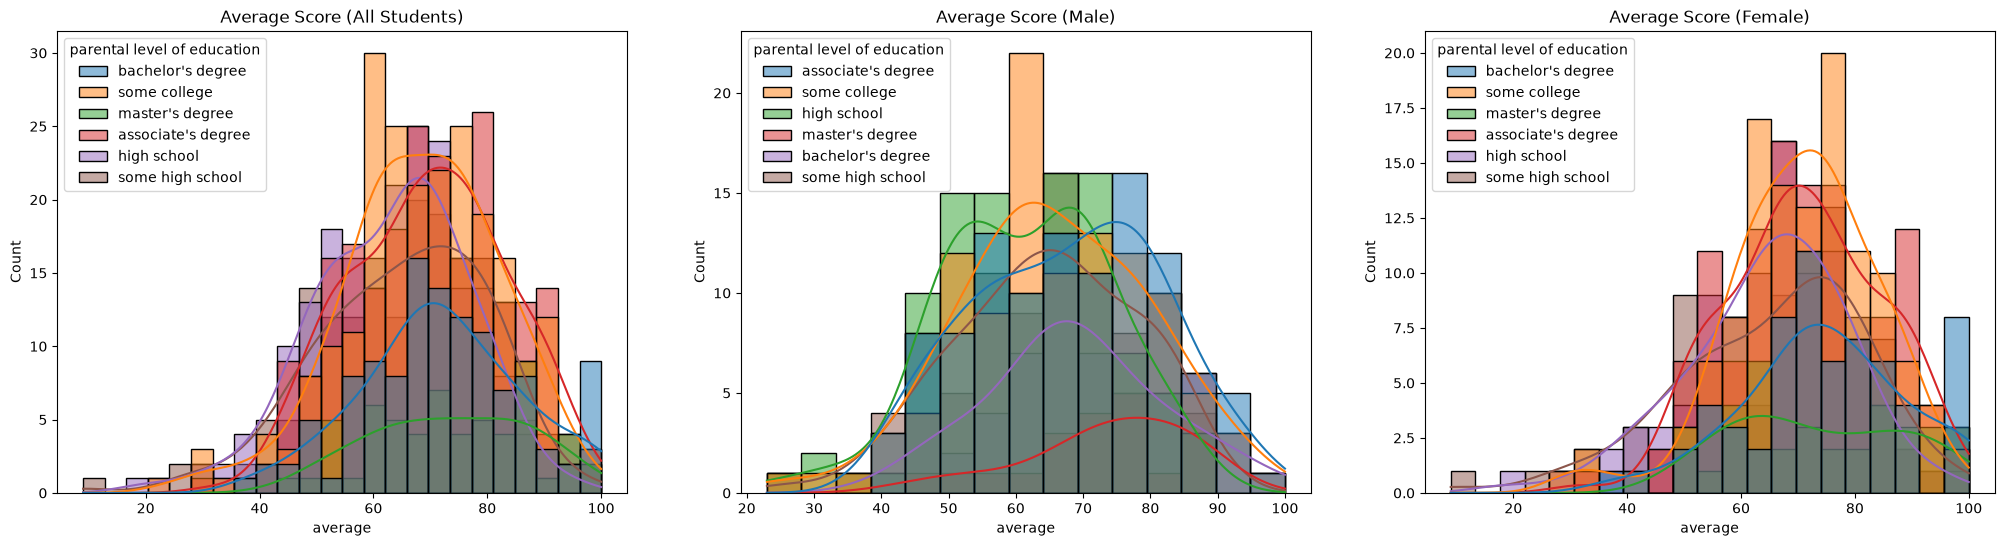

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(131)
ax = sns.histplot(data=data, x='average', kde=True, hue='parental level of education')
plt.title('Average Score (All Students)')

plt.subplot(132)
ax = sns.histplot(data=data[data.gender == 'male'], x='average', kde=True, hue='parental level of education')
plt.title('Average Score (Male)')

plt.subplot(133)
ax = sns.histplot(data=data[data.gender == 'female'], x='average', kde=True, hue='parental level of education')
plt.title('Average Score (Female)')

plt.savefig('images/average_by_parental_education.png')
plt.show()

### I checked whether parental level of education affects students' scores.
- I found that students whose parents have a master's degree score the highest on average (73.6), while students whose parents only went up to high school score the lowest (63.1) a difference of about 10.5 points.
- This pattern holds for both boys and girls, though for girls specifically, I noticed those with a parent who has a bachelor's degree score slightly higher (74.7) than those whose parent has a master's degree (73.6).
- Overall, my conclusion is that the more educated a student's parent is, the better that student tends to perform.
- I want to note that this doesn't necessarily mean parental education directly causes better scores other factors linked to it, such as income or access to resources, could also play a part.

### Does socioeconomic status (lunch type) affect students' performance?

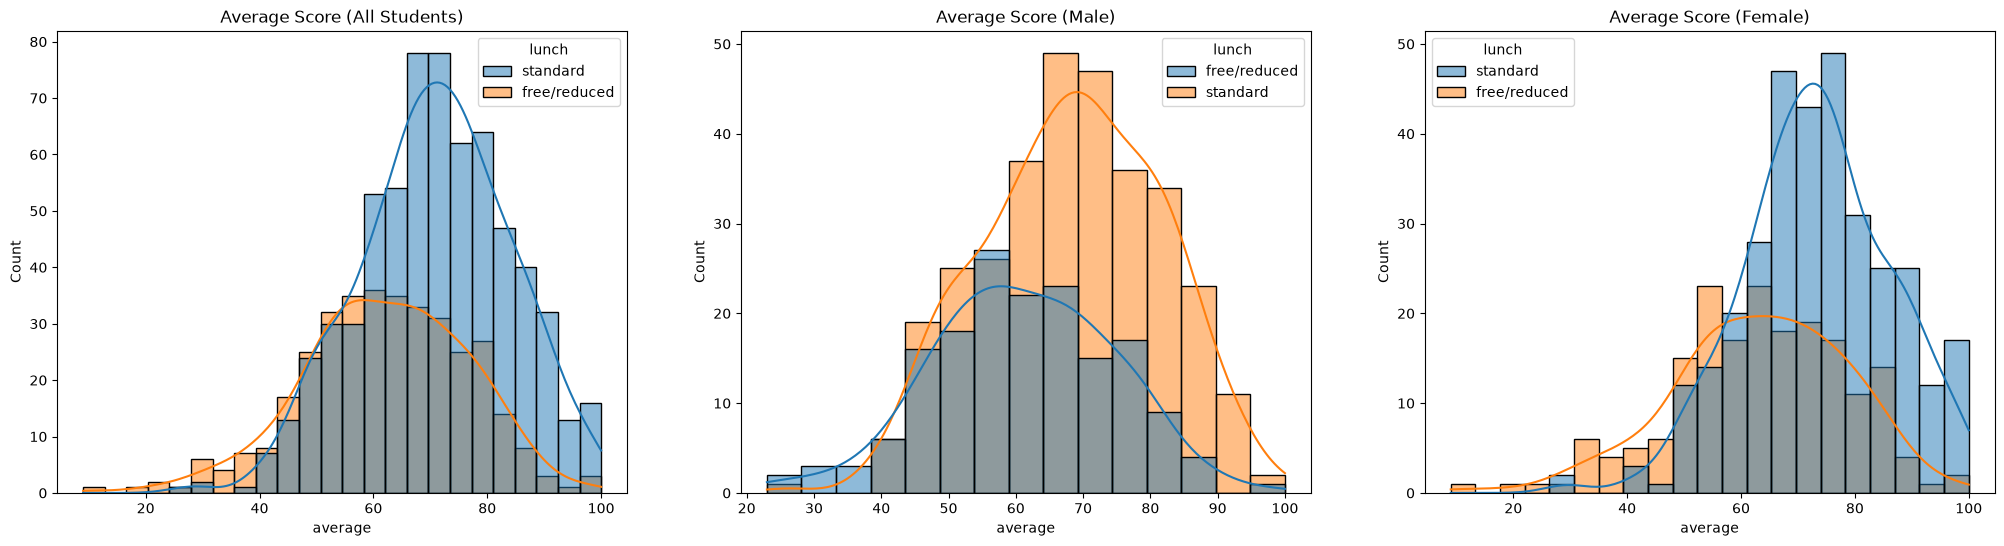

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(131)
ax = sns.histplot(data=data, x='average', kde=True, hue='lunch')
plt.title('Average Score (All Students)')

plt.subplot(132)
ax = sns.histplot(data=data[data.gender == 'male'], x='average', kde=True, hue='lunch')
plt.title('Average Score (Male)')

plt.subplot(133)
ax = sns.histplot(data=data[data.gender == 'female'], x='average', kde=True, hue='lunch')
plt.title('Average Score (Female)')

plt.savefig('images/average_by_lunch.png')
plt.show()

From the plot above, I found that students on standard lunch score higher than those on free/reduced lunch: 70.8 vs 62.2 overall (8.6 point gap), and I noticed the gap is widest for girls (73.2 vs 63.2, 10 points).

## Univariate Analysis

In [35]:
%%capture
data[numeric_features].describe()

I found that scores are fairly centred around 65-70 out of 100 for all three subjects, with a similar spread (std ~15). I also noticed reading and writing have slightly higher averages than maths, and maths has the widest range (min 0).

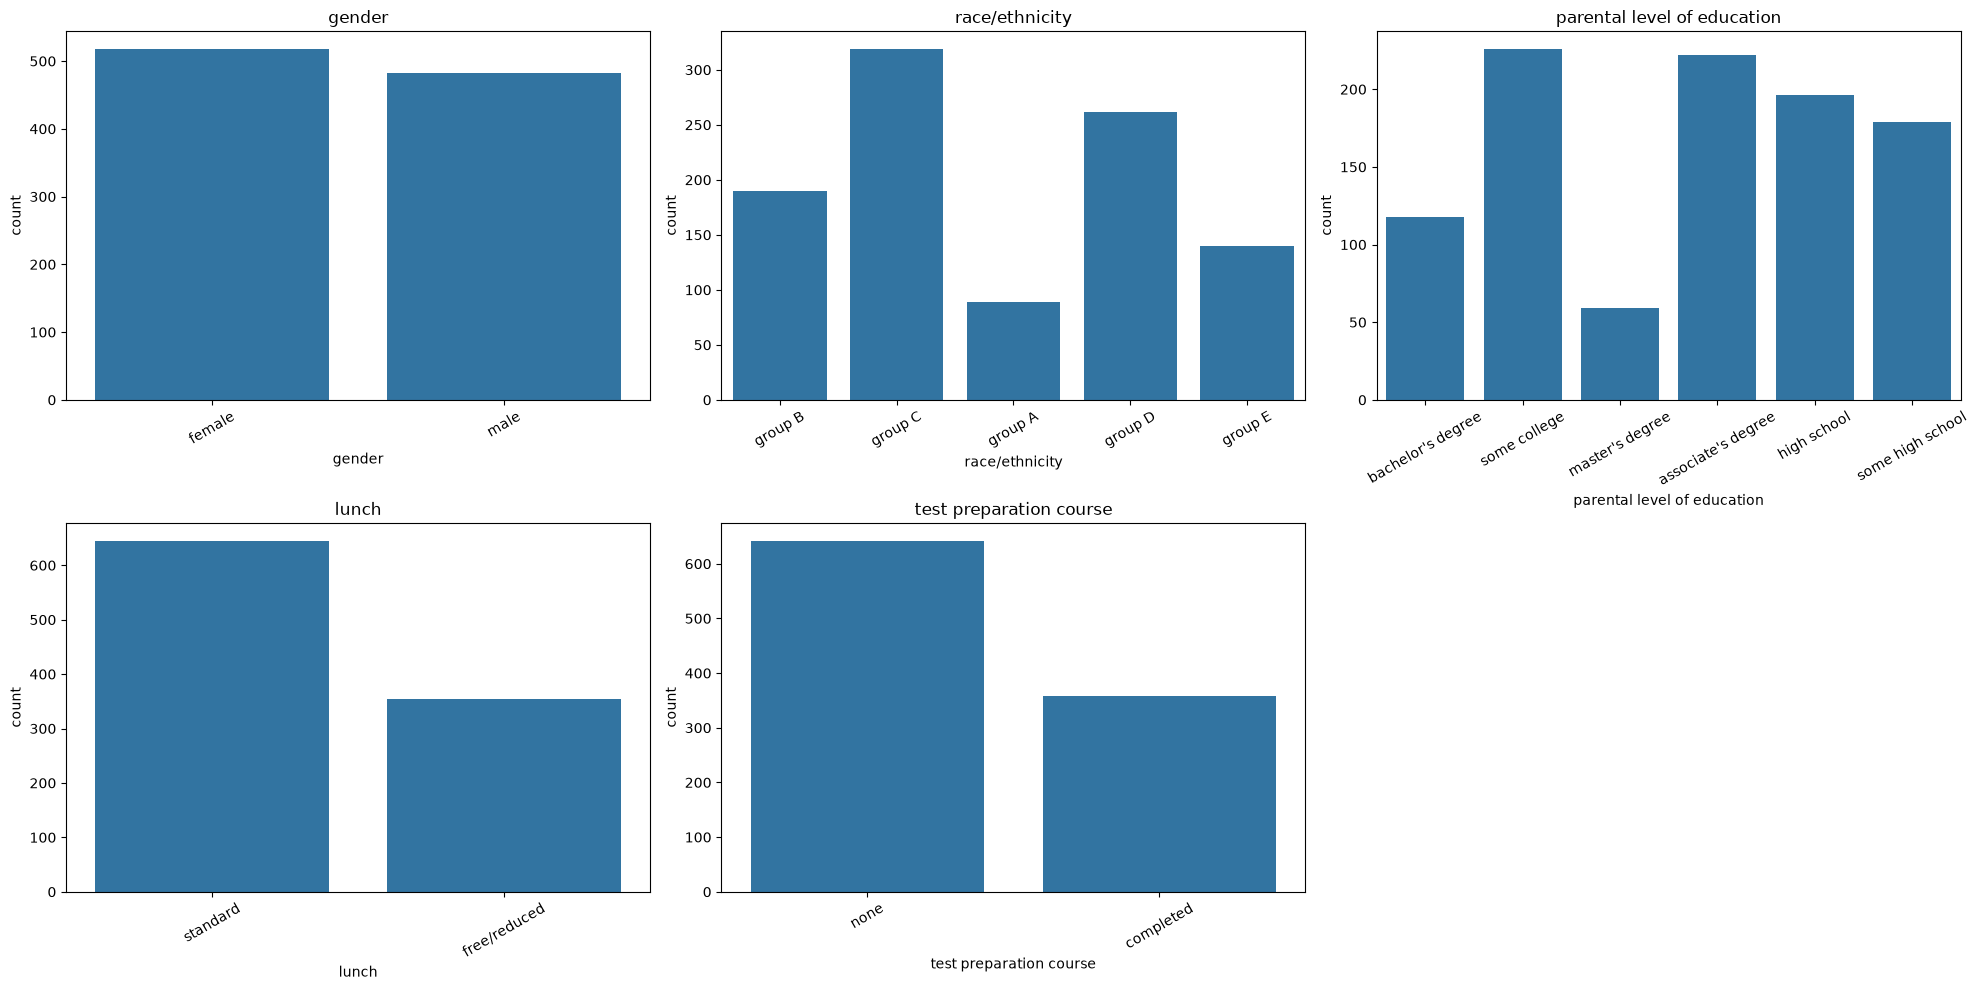

In [38]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
for ax, feature in zip(axs.flatten(), categorical_features):
    sns.countplot(data=data, x=feature, ax=ax)
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=30)

# hide any unused subplot slots
for ax in axs.flatten()[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('images/categorical_counts.png')
plt.show()

I found that gender and lunch are roughly balanced (518/482, 645/355). Race/ethnicity is dominated by group C and D, and I noticed most students did not complete the test preparation course (642 vs 358).

## Bivariate Analysis

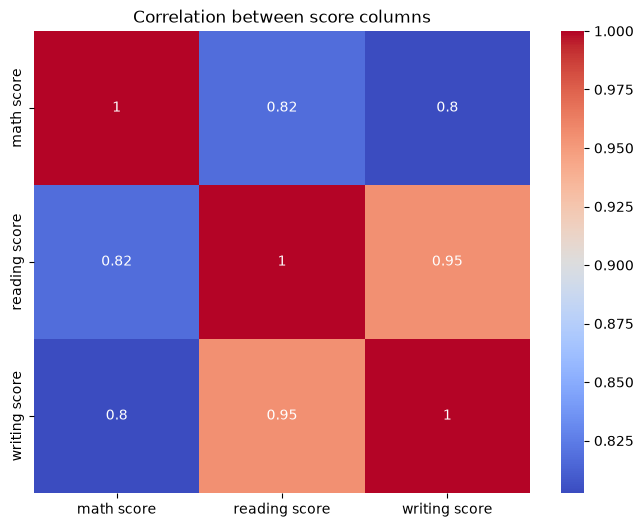

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between score columns')
plt.savefig('images/score_correlation_heatmap.png')
plt.show()

I found that reading and writing scores are very strongly correlated (0.95), which tells me they measure overlapping language skills. I also noticed maths correlates less strongly with both (~0.80-0.82), meaning maths ability is somewhat more independent of reading/writing ability.

## Multivariate Analysis
Here I look at three or more variables together how lunch type and test preparation course jointly affect average score.

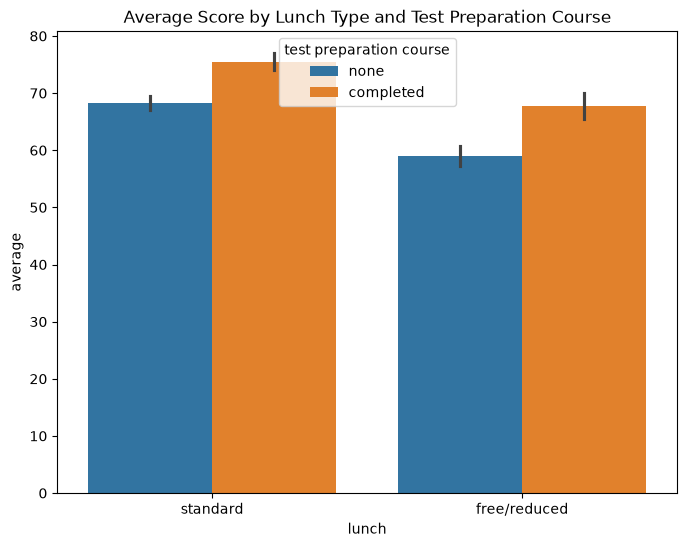

In [40]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='lunch', y='average', hue='test preparation course')
plt.title('Average Score by Lunch Type and Test Preparation Course')
plt.savefig('images/average_by_lunch_and_test_prep.png')
plt.show()

I found that completing the test preparation course helps regardless of lunch type, but the two effects stack: students with standard lunch AND completed test prep score highest (75.5 avg), while free/reduced lunch AND no test prep score lowest (58.9 avg) a combined gap of about 16.6 points, which is bigger than either factor alone.

## Conclusion

Putting the findings together, socio-economic and preparation factors have a bigger, more consistent effect on scores than demographic factors alone:

- **Test preparation and lunch type are the strongest levers**: completing the test prep course and having a standard lunch stack to produce a ~16.6 point gap between the best-off group (standard lunch + completed prep, 75.5 avg) and the worst-off (free/reduced lunch + no prep, 58.9 avg).
- **Parental education matters on its own**: students with a parent holding a master's degree score ~10.5 points higher on average than those whose parent only completed high school, though this is likely a proxy for income/access rather than a direct cause.
- **Gender differences are smaller**: female students score modestly higher on average than male students, mainly driven by reading and writing rather than maths.
- **Reading and writing are one skill, maths is another**: the 0.95 correlation between reading and writing suggests they can likely be modeled together, while maths (0.80-0.82 correlation) carries more independent signal and may need its own features.
- **The data is clean and balanced enough to model**: no duplicates or missing values, and the categorical features (gender, lunch) are reasonably balanced, though race/ethnicity and test preparation course are skewed toward certain categories.

**Implication for modelling**: lunch type, test preparation course, and parental level of education look like the strongest predictors of score outcomes, ahead of gender and race/ethnicity. These should be prioritized as features going into the model-building stage.